# Testing our equation to La Jara data 

In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error

### Model Functions

τ*c evolution - transport capacity (tc)

In [2]:
def evolve_tauc_tc_original(
    tau_star,           # array of Shields stress τ*(t)
    dt,                 # timestep between τ* samples (15 minutes in my case)
    tau_c_min,          # minimum τ*c global
    tau_c_max,          # maximum τ*c global
    event_indices,      # time labels or integer positions where τ*c observations are available
    tau_c_obs,          # observed τ*c values at event_indices
    multiplicative_factor=1, # factor to adjust k values (e.g., for sensitivity testing)
):

    # convert τ* to numeric 1D array and keep index if Series
    if isinstance(tau_star, pd.Series):
        tau_index = tau_star.index
        tau_star_vals = tau_star.to_numpy(dtype=float)
    else:
        tau_index = None
        tau_star_vals = np.asarray(tau_star, dtype=float)

    if tau_star_vals.ndim != 1:
        raise ValueError("tau_star must be 1D after conversion")

    # convert event indices to integer positions in tau_star_vals
    event_labels = np.asarray(event_indices)
    if tau_index is not None:
        event_pos = tau_index.get_indexer(event_labels)

        # allow an initialization observation before forcing starts (e.g., event 0 while tau index starts at 1)
        missing_mask = event_pos < 0
        if np.any(missing_mask) and np.issubdtype(event_labels.dtype, np.number):
            before_start = missing_mask & (event_labels < tau_index.min())
            event_pos[before_start] = 0

        if np.any(event_pos < 0):
            missing_labels = event_labels[event_pos < 0]
            raise ValueError(f"some event indices are not in tau_star index: {missing_labels}")
    else:
        event_pos = np.asarray(event_indices, dtype=int)

    # keep only observed τ*c values that are not NaN
    tau_c_obs_arr = np.asarray(tau_c_obs, dtype=float)
    valid_obs_mask = ~np.isnan(tau_c_obs_arr)
    event_pos_valid = event_pos[valid_obs_mask]
    tau_c_obs_valid = tau_c_obs_arr[valid_obs_mask]

    # initialize modeled τ*c, τ*c_eq, and k array
    n = len(tau_star_vals)
    tau_c = np.full(n, np.nan, dtype=float)  # nan means τ*c is undefined (e.g., during gaps)
    tau_c_pot = np.full(n, np.nan, dtype=float)
    k_array = np.full(n, np.nan, dtype=float)
    tauc_ratio = np.full(n, np.nan, dtype=float)

    tau_c_obs_dict = dict(zip(event_pos_valid, tau_c_obs_valid))
    was_in_gap = True

    i = 0
    while i < n:

        # initialize τ*c when observation exists
        if was_in_gap and i in tau_c_obs_dict:
            tau_c_current = tau_c_obs_dict[i]
            tau_c[i] = tau_c_current
            was_in_gap = False

            # also compute potential τ*c and ratio at initialization timestep
            t = tau_star_vals[i]
            if np.isfinite(t) and np.isfinite(tau_c_current) and tau_c_current > 0:
                ks = 50
                xg = 0.70
                kw = 3.7

                if t / tau_c_current <= 1:
                    tau_conv = tau_c_min + (tau_c_max - tau_c_min) / (1 + np.exp(-ks * (t / tau_c_current - xg)))
                    tau_pot_pure = tau_conv
                else:
                    tau_pot_pure = tau_c_min + (tau_c_max - tau_c_min) * (t / tau_c_current) ** (-kw)

                tau_c_pot[i] = tau_pot_pure
                tauc_ratio[i] = t / tau_c_current
            continue

        # forward evolution with our equation
        if i > 0 and not np.isnan(tau_c[i - 1]):  # if previous τ*c is defined, we can evolve
            tau_c_current = tau_c[i - 1]  # determine previous τ*c
        else:
            # τ* present but τ*c not yet initialized
            i += 1
            continue

        t = tau_star_vals[i]  # current τ*

        if not np.isfinite(t) or not np.isfinite(tau_c_current) or tau_c_current <= 0:
            i += 1
            continue

        # sigmoid parameters from flume data
        ks = 50
        xg = 0.79
        kw = 3.7

        if t / tau_c_current <= 1:  # if τ* is below max τ*c, equilibrium is the max of current τ*c and convergence function
            tau_conv = tau_c_min + (tau_c_max - tau_c_min) / (1 + np.exp(-ks * (t / tau_c_current - xg)))
            tau_pot = max(tau_c_current, tau_conv)  # τ*c cannot decrease below current value if τ* is low
            tau_pot_pure = tau_conv
        else:  # otherwise, equilibrium is given by the weakening function
            tau_conv = tau_c_min + (tau_c_max - tau_c_min) * (t / tau_c_current) ** (-kw)
            tau_pot = tau_conv
            tau_pot_pure = tau_conv

        # calculate k (function of applied tau*)
        k = 0.2924 * (t / tau_c_max) ** 8.6866

        # new tau_c evolution equation
        k_array[i] = k
        tau_c_pot[i] = tau_pot_pure
        tau_c[i] = tau_pot - (tau_pot - tau_c_current) * np.exp(-k * multiplicative_factor * dt)

        # ratio defined against evolved τ*c at this same timestep
        if np.isfinite(tau_c[i]) and tau_c[i] > 0:
            tauc_ratio[i] = t / tau_c[i]
        print('tauc at time:', i, 'is', tau_c[i], '. tau_pot is', tau_c_pot[i], 'and tau/tauc', tauc_ratio[i], 'with k', k_array[i])
        i += 1

    return tau_c, k_array, tau_c_pot, tauc_ratio

In [7]:
def evolve_tauc_tc(
    tau_star,           # array of Shields stress τ*(t)
    dt,                 # timestep between τ* samples (15 minutes in my case)
    tau_c_min,          # minimum τ*c global
    tau_c_max,          # maximum τ*c global
    event_indices,      # time labels or integer positions where τ*c observations are available
    tau_c_obs,          # observed τ*c values at event_indices
    multiplicative_factor=1, # factor to adjust k values (e.g., for sensitivity testing)
):

    # convert τ* to numeric 1D array and keep index if Series
    if isinstance(tau_star, pd.Series):
        tau_index = tau_star.index
        tau_star_vals = tau_star.to_numpy(dtype=float)
    else:
        tau_index = None
        tau_star_vals = np.asarray(tau_star, dtype=float)

    if tau_star_vals.ndim != 1:
        raise ValueError("tau_star must be 1D after conversion")

    # convert event indices to integer positions in tau_star_vals
    event_labels = np.asarray(event_indices)
    if tau_index is not None:
        event_pos = tau_index.get_indexer(event_labels)

        # allow an initialization observation before forcing starts (e.g., event 0 while tau index starts at 1)
        missing_mask = event_pos < 0
        if np.any(missing_mask) and np.issubdtype(event_labels.dtype, np.number):
            before_start = missing_mask & (event_labels < tau_index.min())
            event_pos[before_start] = 0

        if np.any(event_pos < 0):
            missing_labels = event_labels[event_pos < 0]
            raise ValueError(f"some event indices are not in tau_star index: {missing_labels}")
    else:
        event_pos = np.asarray(event_indices, dtype=int)

    # keep only observed τ*c values that are not NaN
    tau_c_obs_arr = np.asarray(tau_c_obs, dtype=float)
    valid_obs_mask = ~np.isnan(tau_c_obs_arr)
    event_pos_valid = event_pos[valid_obs_mask]
    tau_c_obs_valid = tau_c_obs_arr[valid_obs_mask]

    # initialize modeled τ*c, τ*c_eq, and k array
    n = len(tau_star_vals)
    tau_c = np.full(n, np.nan, dtype=float)  # nan means τ*c is undefined (e.g., during gaps)
    tau_c_pot = np.full(n, np.nan, dtype=float)
    k_array = np.full(n, np.nan, dtype=float)
    tauc_ratio = np.full(n, np.nan, dtype=float)
    tau_conv_array = np.full(n, np.nan, dtype=float)

    tau_c_obs_dict = dict(zip(event_pos_valid, tau_c_obs_valid))
    was_in_gap = True

    i = 0
    while i < n-1:
        # determine current τ*
        t = tau_star_vals[i]  # current τ*

        # k equation parameters from flume data
        k = 0.2924 * (t / tau_c_max) ** 8.6866

        # initialize τ*c when observation exists
        if was_in_gap and i in tau_c_obs_dict:
            tau_c_current = tau_c_obs_dict[i]
            tau_c[i] = tau_c_current
            was_in_gap = False
        else:
            tau_c_current = tau_c[i]

        # calculate transport capacity 
        tc = t/tau_c_current  # transport capacity
        tauc_ratio[i] = tc

        # calculate potential τ*c based on current τ*/τ*c
        ks = 50
        xs = 0.79
        kw = 3.7
        if tc <= 1:
            tau_conv = tau_c_min + (tau_c_max - tau_c_min) / (1 + np.exp(-ks * (tc - xs)))
            tau_pot = max(tau_c_current, tau_conv)  # τ*c cannot decrease below current value if τ* is low
            tau_pot_pure = tau_conv
        else:  # otherwise, equilibrium is given by the weakening function
            tau_conv = tau_c_min + (tau_c_max - tau_c_min) * (tc) ** (-kw)
            tau_pot = tau_conv
            tau_pot_pure = tau_conv

        k_array[i] = k
        tau_c_pot[i] = tau_pot_pure
        tau_conv_array[i] = tau_pot

        # evolve τ*c with new equation
        tau_c[i+1] = tau_conv_array[i] - (tau_conv_array[i] - tau_c[i]) * np.exp(-k * multiplicative_factor * dt)
        #print('tauc at time:', i, 'is', tau_c[i], '. tau/tauc', tauc_ratio[i], 'and tau_pot is', tau_c_pot[i], 'with k', k_array[i])
        i += 1

    return tau_c, k_array, tau_c_pot, tauc_ratio

### Testing Flume Data

Import Data

In [4]:
# import data 
tau_star_flume = pd.read_csv('flume_data/applied_shearstress_experiments.csv', index_col='Time')
tauc_measurements_flume = pd.read_csv('flume_data/measured_tauc.csv', index_col='Time')

4000 GPM

In [9]:
tauc_obs_4000 = tauc_measurements_flume['4000'].values
# find min and max of τ*c observations to set bounds for model
tauc_min = tauc_measurements_flume.min().min()
tauc_max = tauc_measurements_flume[-2:].mean().max()

tauc_flume_4000, k_flume_4000, tau_pot_flume_4000, ratio_4000 = evolve_tauc_tc(
    tau_star_flume['4000'],
    dt=1,
    tau_c_min=tauc_min,
    tau_c_max=tauc_max,
    event_indices=tauc_measurements_flume.index,
    tau_c_obs=tauc_obs_4000,
)

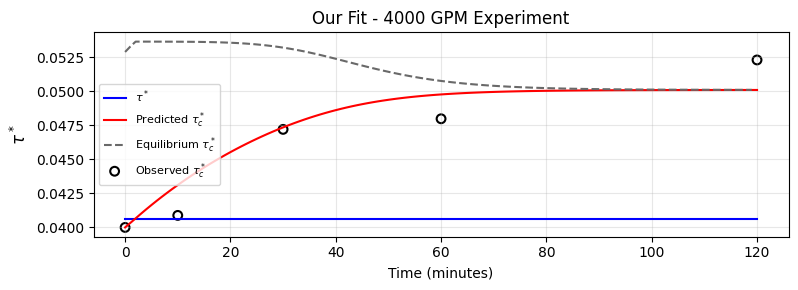

In [10]:
# tau_star is a pd.Series with datetime index
tau_c_pred_series = pd.Series(tauc_flume_4000, index=tau_star_flume.index)
tau_star_series = pd.Series(tau_star_flume['4000'].values, index=tau_star_flume.index)
obs_tauc_series = pd.Series(tauc_obs_4000, index=tauc_measurements_flume.index)
# ockelford fit 
tt = np.linspace(0,120,120)
fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_pot_flume_4000, color='dimgrey', linestyle='--', label=r'Equilibrium $\tau_c^*$', linewidth=1.5)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=40, 
        linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time (minutes)', fontsize=10)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.title('Our Fit - 4000 GPM Experiment', fontsize=12)
plt.tight_layout()
plt.show()

In [11]:
# export applied tau* and predicted tau_c* for 4000 GPM experiment to csv
output_df = pd.DataFrame({
    'Time': tau_star_series.index, 
    'tau_star': tau_star_series.values,
    'tau_c_star': tau_c_pred_series.values,
})
output_df.to_csv('flume_data/results/tau-tauc/monod_predicted_tauc_4000.csv', index=False)

In [15]:
# calculate MAE between our model and ockelford to the observed τ*c values
# align predictions to the observed τ*c timestamps
our_pred_at_obs = tau_c_pred_series.reindex(obs_tauc_series.index).to_numpy(dtype=float)
obs_vals = obs_tauc_series.to_numpy(dtype=float)

# make Ockelford array comparable in length with observed values
n = len(our_pred_at_obs)
obs_vals = obs_vals[:n]
our_pred_at_obs = our_pred_at_obs[:n]

# ignore any NaNs before calculating MAE
valid = (~np.isnan(obs_vals) &
         ~np.isnan(our_pred_at_obs))

mae_our = mean_absolute_error(obs_vals[valid], our_pred_at_obs[valid])

print(f"MAE (our model): {mae_our:.12f}")
print(f"Valid comparison points: {valid.sum()}")

MAE (our model): 0.001273448022
Valid comparison points: 5


5000 GPM

In [16]:
tauc_obs_5000 = tauc_measurements_flume['5000'].values
# find min and max of τ*c observations to set bounds for model

tauc_flume_5000, k_flume_5000, tau_pot_flume_5000, tauc_ratio_5000 = evolve_tauc_tc(
    tau_star_flume['5000'],
    dt=1,
    tau_c_min=tauc_min,
    tau_c_max=tauc_max,
    event_indices=tauc_measurements_flume.index,
    tau_c_obs=tauc_obs_5000,
)

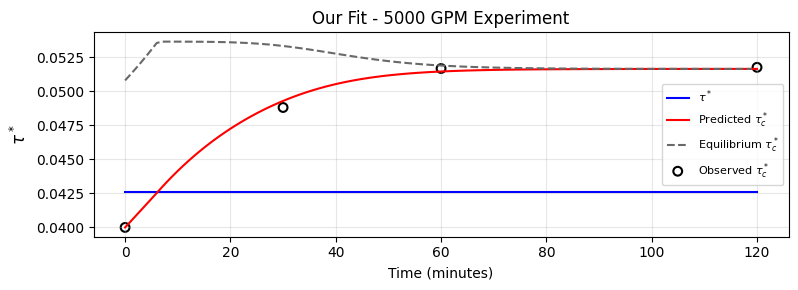

In [17]:
# tau_star is a pd.Series with datetime index
tau_c_pred_series = pd.Series(tauc_flume_5000, index=tau_star_flume.index)
tau_star_series = pd.Series(tau_star_flume['5000'].values, index=tau_star_flume.index)
obs_tauc_series = pd.Series(tauc_obs_5000, index=tauc_measurements_flume.index)
# ockelford fit 
tt = np.linspace(0,120,120)

fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_pot_flume_5000, color='dimgrey', linestyle='--', label=r'Equilibrium $\tau_c^*$', linewidth=1.5)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=40, 
        linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time (minutes)', fontsize=10)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.title('Our Fit - 5000 GPM Experiment', fontsize=12)
plt.tight_layout()
plt.show()

In [18]:
# calculate MAE between our model and ockelford to the observed τ*c values
# align predictions to the observed τ*c timestamps
our_pred_at_obs = tau_c_pred_series.reindex(obs_tauc_series.index).to_numpy(dtype=float)
obs_vals = obs_tauc_series.to_numpy(dtype=float)

# make Ockelford array comparable in length with observed values
n = min(len(obs_vals), len(our_pred_at_obs))
obs_vals = obs_vals[:n]
our_pred_at_obs = our_pred_at_obs[:n]

# ignore any NaNs before calculating MAE
valid = (~np.isnan(obs_vals) &
         ~np.isnan(our_pred_at_obs))

mae_our = mean_absolute_error(obs_vals[valid], our_pred_at_obs[valid])

print(f"MAE (our model): {mae_our:.12f}")
print(f"Valid comparison points: {valid.sum()}")

MAE (our model): 0.000204557983
Valid comparison points: 4


In [19]:
# export applied tau* and predicted tau_c* for 5000 GPM experiment to csv
output_df = pd.DataFrame({
    'Time': tau_star_series.index, 
    'tau_star': tau_star_series.values,
    'tau_c_star': tau_c_pred_series.values,
})
output_df.to_csv('flume_data/results/tau-tauc/monod_predicted_tauc_5000.csv', index=False)

6000 GPM 

In [20]:
tauc_obs_6000 = tauc_measurements_flume['6000'].values
# find min and max of τ*c observations to set bounds for model

tauc_flume_6000, k_flume_6000, tau_pot_flume_6000, tauc_ratio_6000 = evolve_tauc_tc(
    tau_star_flume['6000'],
    dt=1,
    tau_c_min=tauc_min,
    tau_c_max=tauc_max,
    event_indices=tauc_measurements_flume.index,
    tau_c_obs=tauc_obs_6000,
)

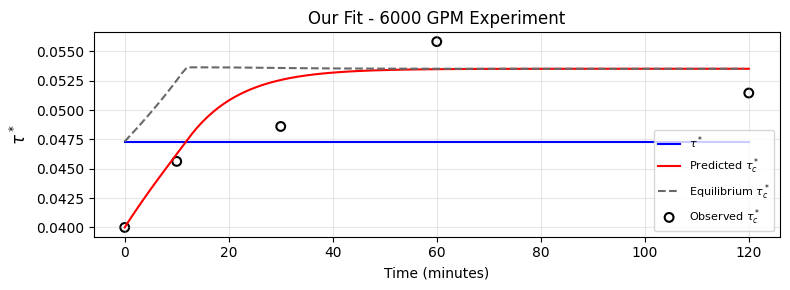

In [21]:
# tau_star is a pd.Series with datetime index
tau_c_pred_series = pd.Series(tauc_flume_6000, index=tau_star_flume.index)
tau_star_series = pd.Series(tau_star_flume['6000'].values, index=tau_star_flume.index)
obs_tauc_series = pd.Series(tauc_obs_6000, index=tauc_measurements_flume.index)
# ockelford fit 
tt = np.linspace(0,120,120)

fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_pot_flume_6000, color='dimgrey', linestyle='--', label=r'Equilibrium $\tau_c^*$', linewidth=1.5)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=40, 
        linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time (minutes)', fontsize=10)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.title('Our Fit - 6000 GPM Experiment', fontsize=12)
plt.tight_layout()
plt.show()

In [22]:
# calculate MAE between our model and ockelford to the observed τ*c values
# align predictions to the observed τ*c timestamps
our_pred_at_obs = tau_c_pred_series.reindex(obs_tauc_series.index).to_numpy(dtype=float)
obs_vals = obs_tauc_series.to_numpy(dtype=float)

# make Ockelford array comparable in length with observed values
n = min(len(obs_vals), len(our_pred_at_obs))
obs_vals = obs_vals[:n]
our_pred_at_obs = our_pred_at_obs[:n]

# ignore any NaNs before calculating MAE
valid = (~np.isnan(obs_vals) &
         ~np.isnan(our_pred_at_obs))

mae_our = mean_absolute_error(obs_vals[valid], our_pred_at_obs[valid])

print(f"MAE (our model): {mae_our:.12f}")
print(f"Valid comparison points: {valid.sum()}")

MAE (our model): 0.001800825516
Valid comparison points: 5


In [23]:
# export applied tau* and predicted tau_c* for 6000 GPM experiment to csv
output_df = pd.DataFrame({
    'Time': tau_star_series.index, 
    'tau_star': tau_star_series.values,
    'tau_c_star': tau_c_pred_series.values,
})
output_df.to_csv('flume_data/results/tau-tauc/monod_predicted_tauc_6000.csv', index=False)

7000 GPM 

In [24]:
tauc_obs_7000 = tauc_measurements_flume['7000'].values
# find min and max of τ*c observations to set bounds for model

tauc_flume_7000, k_flume_7000, tau_pot_flume_7000, tauc_ratio_7000 = evolve_tauc_tc(
    tau_star_flume['7000'],
    dt=1,
    tau_c_min=tauc_min,
    tau_c_max=tauc_max,
    event_indices=tauc_measurements_flume.index,
    tau_c_obs=tauc_obs_7000,
)

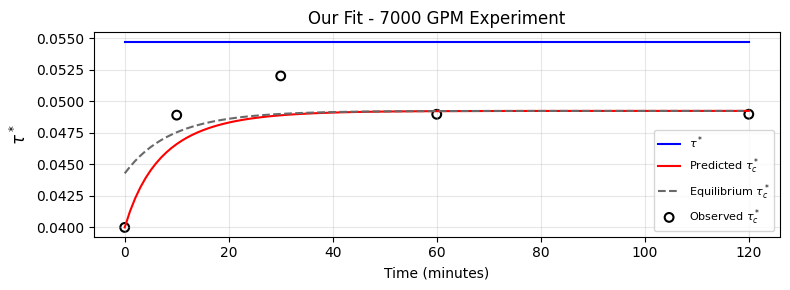

In [25]:
# tau_star is a pd.Series with datetime index
tau_c_pred_series = pd.Series(tauc_flume_7000, index=tau_star_flume.index)
tau_star_series = pd.Series(tau_star_flume['7000'].values, index=tau_star_flume.index)
obs_tauc_series = pd.Series(tauc_obs_7000, index=tauc_measurements_flume.index)
# ockelford fit 
tt = np.linspace(0,120,120)
#ockelford_tauc = tau_eq_flume_7000 - (tau_eq_flume_7000 - tauc_min) * np.exp(-0.488 * tt)

fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_pot_flume_7000, color='dimgrey', linestyle='--', label=r'Equilibrium $\tau_c^*$', linewidth=1.5)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=40, 
        linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time (minutes)', fontsize=10)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.title('Our Fit - 7000 GPM Experiment', fontsize=12)
plt.tight_layout()
plt.show()

In [26]:
# calculate MAE between our model and ockelford to the observed τ*c values
# align predictions to the observed τ*c timestamps
our_pred_at_obs = tau_c_pred_series.reindex(obs_tauc_series.index).to_numpy(dtype=float)
obs_vals = obs_tauc_series.to_numpy(dtype=float)

# make Ockelford array comparable in length with observed values
n = min(len(obs_vals), len(our_pred_at_obs))
obs_vals = obs_vals[:n]
our_pred_at_obs = our_pred_at_obs[:n]

# ignore any NaNs before calculating MAE
valid = (~np.isnan(obs_vals) &
         ~np.isnan(our_pred_at_obs))

mae_our = mean_absolute_error(obs_vals[valid], our_pred_at_obs[valid])

print(f"MAE (our model): {mae_our:.12f}")
print(f"Valid comparison points: {valid.sum()}")

MAE (our model): 0.001183925760
Valid comparison points: 5


In [27]:
# export applied tau* and predicted tau_c* for 7000 GPM experiment to csv
output_df = pd.DataFrame({
    'Time': tau_star_series.index, 
    'tau_star': tau_star_series.values,
    'tau_c_star': tau_c_pred_series.values,
})
output_df.to_csv('flume_data/results/tau-tauc/monod_predicted_tauc_7000.csv', index=False)

#### Plot All Together

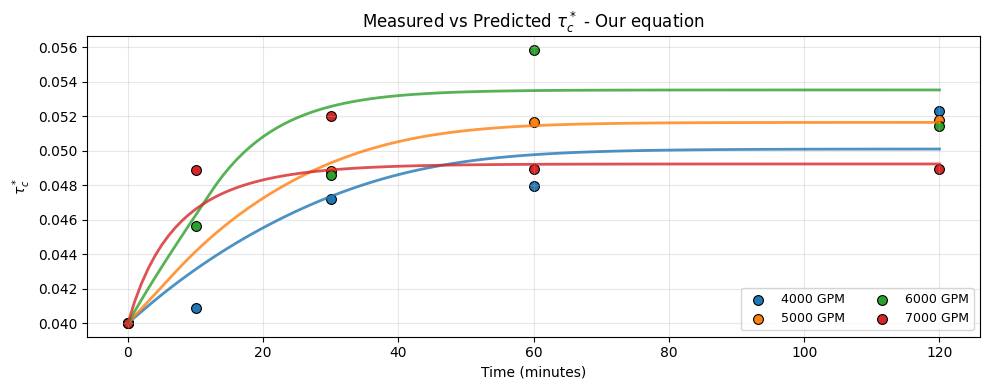

In [28]:
flows = ['4000', '5000', '6000', '7000']
colors = dict(zip(flows, plt.cm.tab10.colors[:4]))

# predicted tau_c* arrays from your evolve_tauc runs
pred_by_flow = {
    '4000': tauc_flume_4000,
    '5000': tauc_flume_5000,
    '6000': tauc_flume_6000,
    '7000': tauc_flume_7000,
}

fig, ax = plt.subplots(figsize=(10, 4))

for flow in flows:
    pred = pred_by_flow.get(flow, None)
    if pred is None:
        continue

    c = colors[flow]

    # time axis from flume tau* table
    time_pred = tau_star_flume.index.to_numpy()
    pred = np.asarray(pred, dtype=float)

    # safety trim in case lengths differ
    n = min(len(time_pred), len(pred))
    ax.plot(
        time_pred[:n],
        pred[:n],
        color=c,
        linewidth=2,
        alpha=0.8
    )

    # observed tau_c* for same flow
    obs_series = tauc_measurements_flume[flow].astype(float)
    valid_obs = ~obs_series.isna()

    ax.scatter(
            obs_series.index[valid_obs],
            obs_series[valid_obs],
            color=c,
            s=50,
            edgecolors='black',
            linewidth=0.8,
            label=f'{flow} GPM'
        )

ax.set_xlabel('Time (minutes)')
ax.set_ylabel(r'$\tau_c^*$')
ax.set_title(r'Measured vs Predicted $\tau_c^*$ - Our equation', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(ncol=2, fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()


### Testing Field Data

Import Data

In [29]:
# import data 
tau_star = pd.read_csv('../../shear_stress_record/average_shear_stress_lajara_full.csv')
tauc_events = pd.read_csv('field_data/tauc_events_exceedance_rising.csv', parse_dates=['datetime'], index_col='datetime')
# convert to datetime and set as index
tau_star['datetime'] = pd.to_datetime(tau_star['datetime']) 
tau_star = tau_star.set_index('datetime')
df_tau_resampled = tau_star.resample('1min').ffill()  # forwardfill to keep tau* constant during gaps
# create continuous 1-minute time index from first timestamp to last
continuous_index = pd.date_range(start=tau_star.index.min(), end=tau_star.index.max(), freq='1min')
# change column name to 'tau' for clarity
df_tau = tau_star.rename(columns={'shear_stress': 'tau'})
# delete everything before 2022-07-14 (we don't care about earlier times)
df_tau = df_tau[df_tau.index >= '2022-07-14 15:00']


print(f"Data gaps (NaNs): {df_tau['tau'].isna().sum().sum()}")
# show what dates are the data gaps
print("Data gaps (NaN indices):", df_tau[df_tau['tau'].isna()].index)

# convert tau to dimenstionless Shields stress τ*
rho_s = 2650.0  # sediment density, kg/m3
rho = 1000.0   # fluid density, kg/m3
g = 9.81       # gravitational acceleration, m/s2
d50 = 0.04364    # median grain diameter, m

df_tau['tau_star'] = df_tau['tau'] / ((rho_s - rho) * g * d50)

# build integer index mapping
time_to_index = pd.Series(
    np.arange(len(df_tau)), 
    index=df_tau.index
)
event_indices = time_to_index.loc[tauc_events.index].to_numpy() # integer indices of event times
tau_c_obs = tauc_events["tauc"].to_numpy() # observed τ*c values
tau_star = df_tau["tau_star"].to_numpy() # τ* time series array

Data gaps (NaNs): 0
Data gaps (NaN indices): DatetimeIndex([], dtype='datetime64[ns]', name='datetime', freq=None)


Run Full La Jara Record

In [30]:
tauc_obs_lajara = tauc_events["tauc"].to_numpy()
# find min and max of τ*c observations to set bounds for model
tauc_min_lajara = tauc_obs_lajara.min() 
tauc_max_lajara = tauc_obs_lajara.max()

Final:

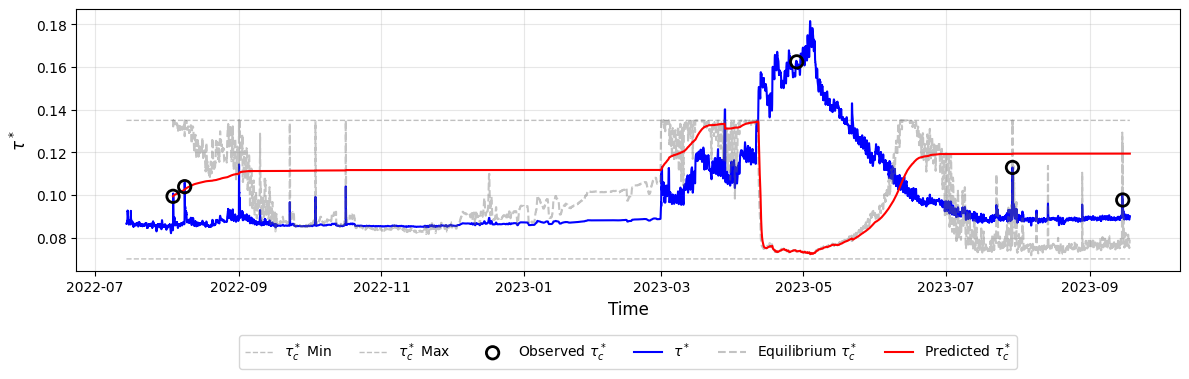

In [32]:
#tauc_min_lajara = tauc_obs_lajara.min()* 0.95
#tauc_max_lajara = tauc_obs_lajara.max() * 1.01
tauc_min_lajara = 0.07
tauc_max_lajara = 0.135

tauc_lajara, k_lajara, tau_eq_lajara, tauc_ratio_field = evolve_tauc_tc(
    tau_star,
    dt=15, # 15 minute timestep
    tau_c_min=tauc_min_lajara,
    tau_c_max=tauc_max_lajara,
    event_indices=event_indices,
    tau_c_obs=tauc_obs_lajara,
    multiplicative_factor=0.002
)
tau_c_pred_series = pd.Series(tauc_lajara, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

fig, ax = plt.subplots(figsize=(12, 4))
# horiztonal min and max lines 
ax.plot(tau_c_pred_series.index, [tauc_min_lajara]*len(tau_c_pred_series), color='silver', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series.index, [tauc_max_lajara]*len(tau_c_pred_series), color='silver', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
ax.scatter(tauc_events.index, tauc_obs_lajara, facecolors="none", edgecolors="black", s=80, linewidth=2, label=r"Observed $\tau^*_c$", zorder=5,)

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_star_series.index, tau_eq_lajara, color='dimgrey', linestyle='--', label=r'Equilibrium $\tau_c^*$', linewidth=1.5, alpha=0.4)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.legend(fontsize=10, loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=6)
ax.grid(True, alpha=0.3)

#plt.title(r'Using $\tau^*$/$\tau_c^*$ balance equation', fontsize=14)
# modify dates on x-axis to be more readable
#plt.xlim(pd.Timestamp("2023-07-20"), pd.Timestamp("2023-08-05"))
plt.tight_layout()
plt.show()